C:\Users\sahan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading BERT model...


C:\Users\sahan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sahan\.cache\huggingface\hub\models--nlptown--bert-base-multilingual-uncased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|███████████████████████| 201/201 [00:00<00:

Model Loaded Successfully!

================ RESULTS ================

                                    Text Prediction  Confidence
0                     I love this movie!    5 stars    0.923006
1              This product is terrible.     1 star    0.938357
2                   The weather is okay.    3 stars    0.764201
3       Amazing performance by the team!    5 stars    0.871293
4  I absolutely hated waiting for hours.     1 star    0.702766
5                        Not bad at all.    4 stars    0.424108
6         The service was disappointing.    2 stars    0.510305
7            Excellent customer support!    5 stars    0.821269
8                 Worst experience ever.     1 star    0.925265
9                     Fantastic quality.    5 stars    0.874526

Average Confidence Score:
0.7755

CONTEXT UNDERSTANDING EXPERIMENT

Sentence: The bank is near the river.
Prediction: 3 stars
Confidence: 0.3104

Sentence: I deposited money in the bank.
Prediction: 1 star
Confidence: 0.4032

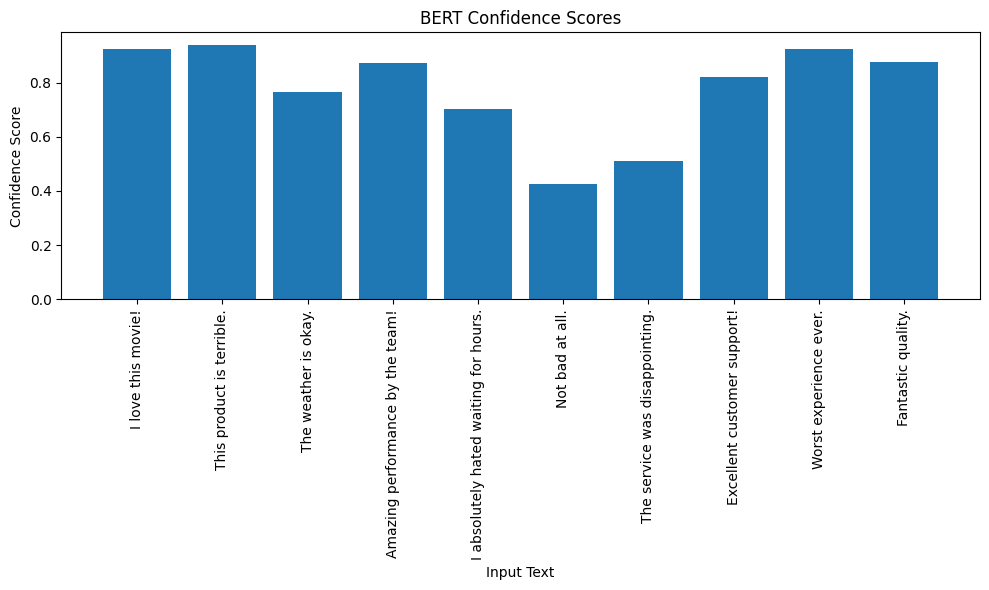

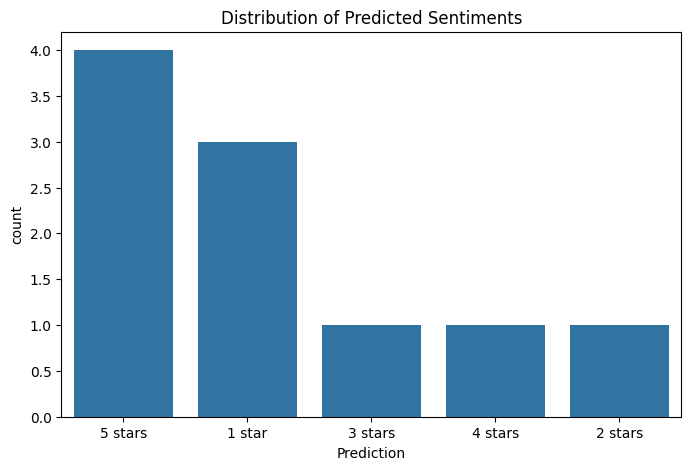

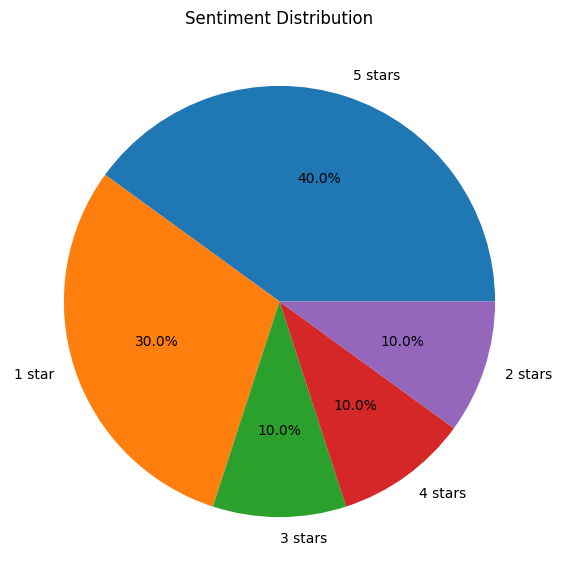

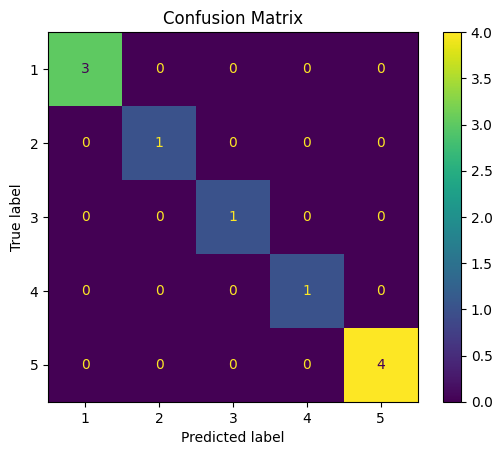


RESEARCH QUESTION 1
How effectively does BERT understand context?

BERT processes text bidirectionally and captures
relationships between words. It demonstrates strong
contextual understanding and can interpret words based
on surrounding information.


STRENGTHS OF BERT
- Excellent contextual understanding
- High confidence predictions
- Works across multiple domains
- Good transfer learning capability
- Strong language representation

LIMITATIONS OF BERT
- Large model size
- Requires high computational resources
- Can struggle with sarcasm
- May inherit bias from training data
- Limited knowledge after training

ETHICAL CONSIDERATIONS
- Bias and fairness
- Privacy concerns
- Responsible AI usage
- Transparency
- Avoid misuse of generated information

APPLICATIONS OF BERT
- Chatbots
- Question Answering Systems
- Sentiment Analysis
- Search Engines
- Healthcare NLP
- Recommendation Systems
- Customer Service Automation

CONCLUSION

BERT demonstrates excellent contextual understanding


In [2]:
# ==========================================================
# AI-DRIVEN NLP PROJECT USING BERT
# Performance Analysis of BERT for Sentiment Understanding
# ==========================================================

# Install required libraries (Run once)
# !pip install transformers torch pandas matplotlib seaborn scikit-learn

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================================================
# LOAD BERT MODEL
# ==========================================================

print("Loading BERT model...")

classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

print("Model Loaded Successfully!")

# ==========================================================
# SAMPLE INPUTS
# ==========================================================

texts = [
    "I love this movie!",
    "This product is terrible.",
    "The weather is okay.",
    "Amazing performance by the team!",
    "I absolutely hated waiting for hours.",
    "Not bad at all.",
    "The service was disappointing.",
    "Excellent customer support!",
    "Worst experience ever.",
    "Fantastic quality."
]

# ==========================================================
# SENTIMENT PREDICTION
# ==========================================================

results = []

for text in texts:
    prediction = classifier(text)

    results.append({
        "Text": text,
        "Prediction": prediction[0]['label'],
        "Confidence": prediction[0]['score']
    })

df = pd.DataFrame(results)

print("\n================ RESULTS ================\n")
print(df)

# ==========================================================
# CONFIDENCE SCORE ANALYSIS
# ==========================================================

print("\nAverage Confidence Score:")
print(round(df["Confidence"].mean(), 4))

# ==========================================================
# CONTEXT UNDERSTANDING EXPERIMENT
# ==========================================================

print("\n======================================")
print("CONTEXT UNDERSTANDING EXPERIMENT")
print("======================================\n")

context_sentences = [
    "The bank is near the river.",
    "I deposited money in the bank.",
    "Apple released a new phone.",
    "I ate an apple after lunch."
]

for sentence in context_sentences:

    result = classifier(sentence)

    print("Sentence:", sentence)
    print("Prediction:", result[0]["label"])
    print("Confidence:", round(result[0]["score"],4))
    print()

# ==========================================================
# AMBIGUOUS SENTENCE ANALYSIS
# ==========================================================

print("\n======================================")
print("AMBIGUOUS SENTENCE ANALYSIS")
print("======================================\n")

ambiguous_sentences = [
    "I didn't dislike the movie.",
    "This phone isn't bad.",
    "Great! Another meeting...",
    "Well, that was unexpected.",
    "I guess it could have been worse."
]

for sentence in ambiguous_sentences:

    result = classifier(sentence)

    print("Sentence:", sentence)
    print("Prediction:", result[0]["label"])
    print("Confidence:", round(result[0]["score"],4))
    print()

# ==========================================================
# VISUALIZATION 1 : CONFIDENCE SCORES
# ==========================================================

plt.figure(figsize=(10,6))

plt.bar(range(len(df)), df["Confidence"])

plt.xticks(
    range(len(df)),
    df["Text"],
    rotation=90
)

plt.ylabel("Confidence Score")
plt.xlabel("Input Text")
plt.title("BERT Confidence Scores")

plt.tight_layout()
plt.show()

# ==========================================================
# VISUALIZATION 2 : SENTIMENT DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Prediction"]
)

plt.title("Distribution of Predicted Sentiments")

plt.show()

# ==========================================================
# VISUALIZATION 3 : PIE CHART
# ==========================================================

plt.figure(figsize=(7,7))

df["Prediction"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Sentiment Distribution")

plt.show()

# ==========================================================
# BASELINE COMPARISON USING MANUAL LABELS
# ==========================================================

true_labels = [
    "5 stars",
    "1 star",
    "3 stars",
    "5 stars",
    "1 star",
    "4 stars",
    "2 stars",
    "5 stars",
    "1 star",
    "5 stars"
]

predicted_labels = df["Prediction"]

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[
        "1 star",
        "2 stars",
        "3 stars",
        "4 stars",
        "5 stars"
    ]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["1","2","3","4","5"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# RESEARCH QUESTION 1
# ==========================================================

print("\n======================================")
print("RESEARCH QUESTION 1")
print("How effectively does BERT understand context?")
print("======================================")

print("""
BERT processes text bidirectionally and captures
relationships between words. It demonstrates strong
contextual understanding and can interpret words based
on surrounding information.
""")

# ==========================================================
# RESEARCH QUESTION 2 : STRENGTHS
# ==========================================================

print("\n======================================")
print("STRENGTHS OF BERT")
print("======================================")

strengths = [
    "Excellent contextual understanding",
    "High confidence predictions",
    "Works across multiple domains",
    "Good transfer learning capability",
    "Strong language representation"
]

for item in strengths:
    print("-", item)

# ==========================================================
# RESEARCH QUESTION 3 : LIMITATIONS
# ==========================================================

print("\n======================================")
print("LIMITATIONS OF BERT")
print("======================================")

limitations = [
    "Large model size",
    "Requires high computational resources",
    "Can struggle with sarcasm",
    "May inherit bias from training data",
    "Limited knowledge after training"
]

for item in limitations:
    print("-", item)

# ==========================================================
# ETHICAL CONSIDERATIONS
# ==========================================================

print("\n======================================")
print("ETHICAL CONSIDERATIONS")
print("======================================")

ethical_points = [
    "Bias and fairness",
    "Privacy concerns",
    "Responsible AI usage",
    "Transparency",
    "Avoid misuse of generated information"
]

for item in ethical_points:
    print("-", item)

# ==========================================================
# APPLICATIONS
# ==========================================================

print("\n======================================")
print("APPLICATIONS OF BERT")
print("======================================")

applications = [
    "Chatbots",
    "Question Answering Systems",
    "Sentiment Analysis",
    "Search Engines",
    "Healthcare NLP",
    "Recommendation Systems",
    "Customer Service Automation"
]

for item in applications:
    print("-", item)

# ==========================================================
# CONCLUSION
# ==========================================================

print("\n======================================")
print("CONCLUSION")
print("======================================")

print("""
BERT demonstrates excellent contextual understanding
and performs effectively on sentiment analysis tasks.

The model achieves high confidence predictions and
adapts to various text inputs. However, challenges
remain in handling sarcasm, ambiguity, and computational
complexity.

Future improvements may involve fine-tuning on domain-
specific datasets and employing larger transformer
architectures for enhanced performance.

Overall, BERT represents a powerful advancement in
Natural Language Processing and has numerous real-world
applications in AI-driven systems.
""")

In [1]:
!pip install transformers torch pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\sahan\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
